## Import packages

In [14]:
import os, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from scipy.stats import chi2 as scipy_chi2

## Data preparation

### select features

In [5]:
df = pd.read_csv("../../data/data_merged.csv")

exclude = ["BNPL1", "BNPL3"] + ["Unnamed: 0", "weight", "year",
           "BNPL4_a","BNPL4_b","BNPL4_c","BNPL4_d","BNPL4_e","BNPL4_f", "BNPL1A","BNPL5"]
all_cols   = [c for c in df.columns if c not in exclude]
miss_rates = df[all_cols].isna().mean()
high_miss  = miss_rates[miss_rates > 0.50].index.tolist()
feat_cols  = [c for c in all_cols if c not in high_miss]
df_feat = df[feat_cols].copy()

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_2042/637806062.py:1: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: BNPL1A, 8: BNPL5, 9: EF5D) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/data_merged.csv")


### data pre-processing

In [6]:
# ═════════════════════
# convert data
# ═════════════════════
# Ordinal encoding
ordinal_maps = {
    "ppfs1482": {"Very poor":1,"Poor":2,"Fair":3,"Good":4,"Excellent":5,
                 "Don\u2019t know":np.nan},
    "A6":       {"Not confident":1,"Somewhat confident":2,"Very confident":3,
                 "Don\u2019t know":np.nan},
    "ppinc7":   {"Less than $10,000":1,"$10,000 to $24,999":2,
                 "$25,000 to $49,999":3,"$50,000 to $74,999":4,
                 "$75,000 to $99,999":5,"$100,000 to $149,999":6,
                 "$150,000 or more":7},
    "ppeducat": {"No high school diploma or GED":1,
                 "High school graduate (high school diploma or the equivalent GED)":2,
                 "Some college or Associate\u2019s degree":3,
                 "Bachelor\u2019s degree or higher":4},
    "I20":      {"Less than your income":1,"The same as your income":2,
                 "More than your income":3},
    "C4A":      {"Never carried an unpaid balance (always pay in full)":1,
                 "Once":2,"Some of the time":3,"Most or all of the time":4},
    "ppfsasset":{"Under $50,000":1,"$50,000 - $99,999":2,
                 "$100,000 - $249,999":3,"$250,000 - $499,999":4,
                 "$500,000 - $999,999":5,"$1,000,000 or more":6,
                 "Not sure":np.nan},
    "INF4":     {"Much worse":1,"Somewhat worse":2,"Little or no effect":3,
                 "Somewhat better":4,"Much better":5},
    "C3P":      {"Did not pay or paid less than the minimum payment on at least one card":1,
                 "Paid at least the minimum payment on all credit cards":2,
                 "Did not use any of my credit cards so had no balances":3},
}
for col, m in ordinal_maps.items():
    if col in df_feat.columns:
        df_feat[col] = df_feat[col].map(m)

# binary encoding
binary_cols = [c for c in df_feat.columns
               if df_feat[c].dropna().isin(["Yes","No"]).all()]
for c in binary_cols:
    df_feat[c] = df_feat[c].map({"Yes":1,"No":0})

# nominal encoding
nominal_cols = [c for c in ["ppethm","ppgender","ppemploy","ppmarit5"]
                if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=nominal_cols, drop_first=True, dtype=float)

# ═════════════════════
# fill in na with median
# ═════════════════════
imputer  = SimpleImputer(strategy="median")
X_imp    = imputer.fit_transform(df_feat) # fill in with median
X_df     = pd.DataFrame(X_imp, columns=df_feat.columns)

# ═════════════════════
# rescale
# ═════════════════════
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
X_std    = pd.DataFrame(X_scaled, columns=df_feat.columns)

### KMO — KAISER-MEYER-OLKIN MEASURE OF SAMPLING ADEQUACY

In [18]:
# calculate the KMO
n_features = X_scaled.shape[1]
n_obs      = X_scaled.shape[0]

sample_idx = np.random.choice(n_obs, size=min(10000, n_obs), replace=False)
X_sample   = X_scaled[sample_idx]

kmo_per_var, kmo_overall = calculate_kmo(X_sample)

def kmo_label(v):
    if   v >= 0.90: return "Marvelous"
    elif v >= 0.80: return "Meritorious"
    elif v >= 0.70: return "Middling"
    elif v >= 0.60: return "Mediocre"
    elif v >= 0.50: return "Miserable"
    else:           return "Unacceptable"

print(f"\n  ► Overall KMO:  {kmo_overall:.4f}  [{kmo_label(kmo_overall)}]")

kmo_df = pd.DataFrame({
    "feature":    df_feat.columns,
    "KMO":        kmo_per_var,
    "label":      [kmo_label(v) for v in kmo_per_var]
}).sort_values("KMO")

print(kmo_df)


  ► Overall KMO:  0.6089  [Mediocre]


/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


,feature,KMO,label
23,"ppethm_Other, Non-Hispanic",0.093644,Unacceptable
22,ppethm_Hispanic,0.200910,Unacceptable
21,"ppethm_Black, Non-Hispanic",0.217355,Unacceptable
30,ppmarit5_Separated,0.276739,Unacceptable
24,"ppethm_White, Non-Hispanic",0.323881,Unacceptable
31,ppmarit5_Widowed,0.340327,Unacceptable
27,ppemploy_Working part-time,0.437115,Unacceptable
2,EF3_c,0.468911,Unacceptable
26,ppemploy_Working full-time,0.515760,Miserable
28,ppmarit5_Never married,0.549935,Miserable


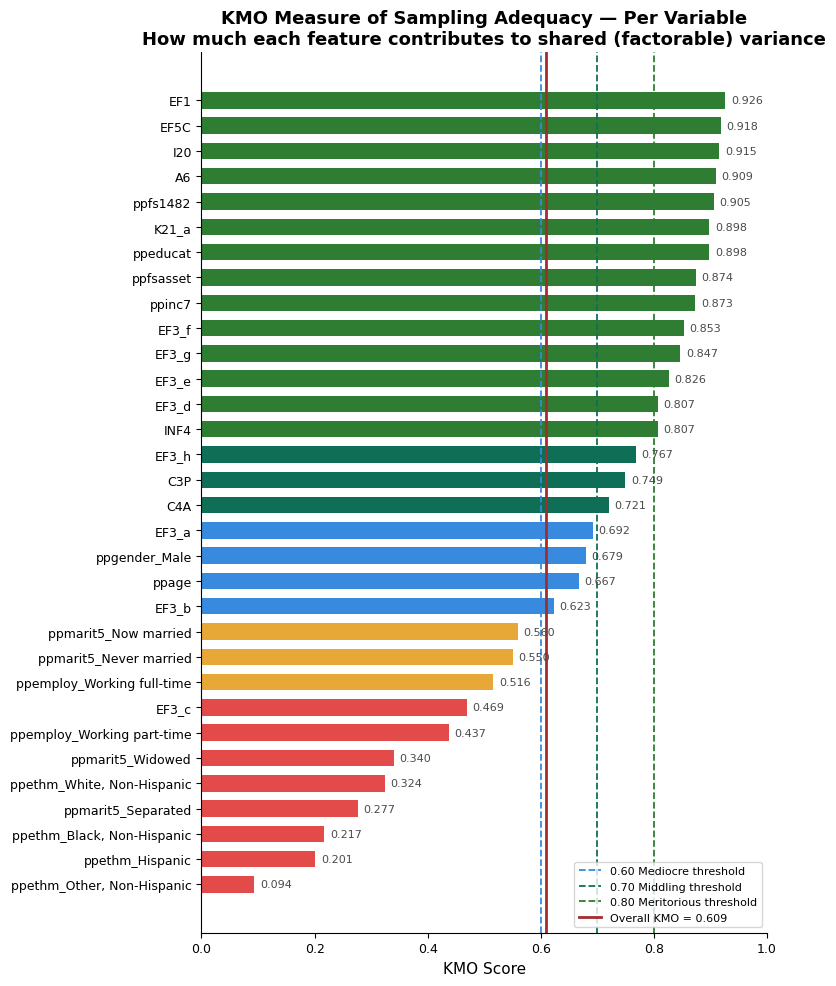

In [29]:
# plot individual kMO
BLUE   = "#185FA5"
LBLUE  = "#378ADD"
RED    = "#A32D2D"
LRED   = "#E24B4A"
TEAL   = "#0F6E56"
AMBER  = "#854F0B"
LAMBER = "#E8A838"
GRAY   = "#4A4A4A"
LGRAY  = "#9A9A9A"
GREEN  = "#2E7D32"
BG     = "white"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

def kmo_color(v):
    if v >= 0.80: return GREEN
    if v >= 0.70: return TEAL
    if v >= 0.60: return LBLUE
    if v >= 0.50: return LAMBER
    return LRED

colors_kmo = [kmo_color(v) for v in kmo_df["KMO"]]

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(kmo_df["feature"], kmo_df["KMO"], color=colors_kmo, height=0.65)
ax.axvline(0.60, color=LBLUE,  ls="--", lw=1.3, label="0.60 Mediocre threshold")
ax.axvline(0.70, color=TEAL,   ls="--", lw=1.3, label="0.70 Middling threshold")
ax.axvline(0.80, color=GREEN,  ls="--", lw=1.3, label="0.80 Meritorious threshold")
ax.axvline(kmo_overall, color=RED, ls="-", lw=2.0,
           label=f"Overall KMO = {kmo_overall:.3f}")
ax.set_xlim(0, 1.0)
ax.set_xlabel("KMO Score")
ax.set_title("KMO Measure of Sampling Adequacy — Per Variable\n"
             "How much each feature contributes to shared (factorable) variance")
ax.legend(fontsize=8, loc="lower right")
for bar, val in zip(bars, kmo_df["KMO"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8, color=GRAY)
plt.tight_layout()
fig.savefig("./img/kmo_per_variable.png", dpi=150, bbox_inches="tight")
plt.show()

In [121]:
# keep high KMO variable and re-analyze overall KMO
include_cols = list(kmo_df.loc[kmo_df['KMO']>=0.85,'feature'])
included_cols_idx = [i for i, col in enumerate(df_feat.columns) if col in include_cols]
X_sample_high_kmo = X_sample_high_kmo = X_sample[:,included_cols_idx]

kmo_per_var_high_kmo, kmo_overall_high_kmo = calculate_kmo(X_sample_high_kmo)
print(f"\n  ► Overall KMO after taking low KMO variables:  {kmo_overall_high_kmo:.4f}  [{kmo_label(kmo_overall_high_kmo)}]")


  ► Overall KMO after taking low KMO variables:  0.8441  [Meritorious]


### FIT PCA

In [ ]:
pca = PCA(random_state=42).fit(X_sample_high_kmo)
eigenvalues = pca.explained_variance_
ev          = pca.explained_variance_ratio_
cumulative  = np.cumsum(ev)
kaiser_n  = int(np.sum(eigenvalues > 1))
n_comp_80 = int(np.argmax(cumulative >= 0.80)) + 1

pca   = PCA(n_components=kaiser_n, random_state=42)
X_pca = pca.fit_transform(X_sample_high_kmo)

pc_cols  = [f"PC{i+1}" for i in range(kaiser_n)]
loadings = pd.DataFrame(pca.components_.T, index=include_cols, columns=pc_cols)

print(f"Kaiser components : {kaiser_n}  ({cumulative[kaiser_n-1]*100:.1f}% variance)")
print(f"For 80% variance  : {n_comp_80} components")


Kaiser components : 2  (42.2% variance)
For 80% variance  : 7 components


(0.0, 105.0)

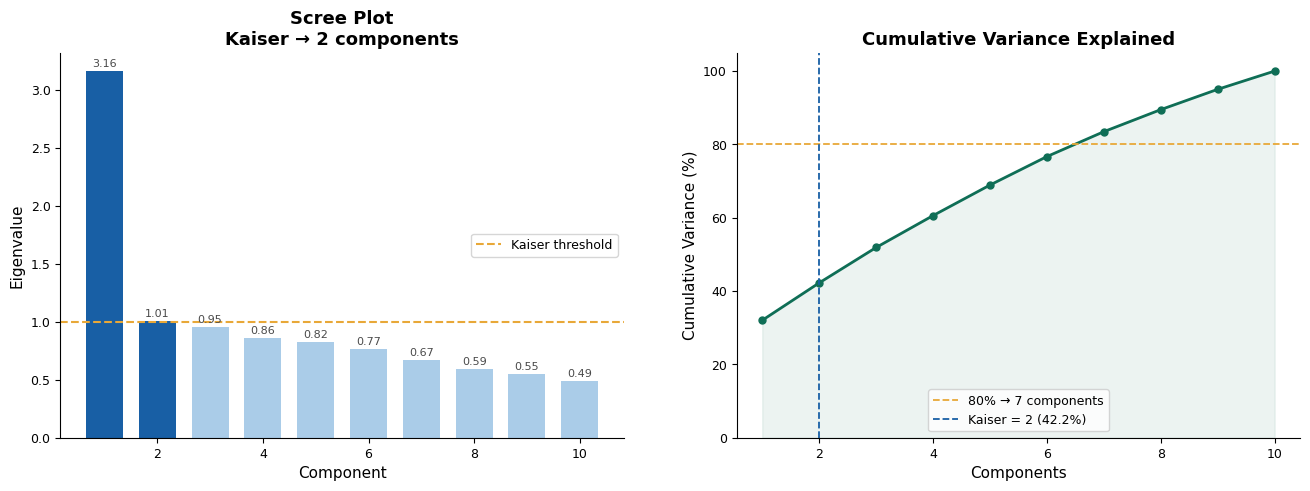

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
n = len(eigenvalues)
ax.bar(range(1, n+1), eigenvalues,
       color=[BLUE if e > 1 else "#AACCE8" for e in eigenvalues], width=0.7)
ax.axhline(1.0, color="#E8A838", ls="--", lw=1.5, label="Kaiser threshold")
ax.plot(range(1, n+1), cumulative * max(eigenvalues),   # secondary axis trick
        color=TEAL, lw=1.5, marker="o", ms=4, ls="--", alpha=0.0)  # hidden, shown below
ax.set_xlabel("Component"); ax.set_ylabel("Eigenvalue")
ax.set_title(f"Scree Plot\nKaiser → {kaiser_n} components")
ax.legend(fontsize=9)
for i, e in enumerate(eigenvalues):
    ax.text(i+1, e+0.04, f"{e:.2f}", ha="center", fontsize=8, color=GRAY)

# ── Cumulative variance ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, n+1), cumulative*100, color=TEAL, lw=2, marker="o", ms=5)
ax2.fill_between(range(1, n+1), cumulative*100, alpha=0.08, color=TEAL)
ax2.axhline(80, color="#E8A838", ls="--", lw=1.3,
            label=f"80% → {n_comp_80} components")
ax2.axvline(kaiser_n, color=BLUE, ls="--", lw=1.3,
            label=f"Kaiser = {kaiser_n} ({cumulative[kaiser_n-1]*100:.1f}%)")
ax2.set_xlabel("Components"); ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_title("Cumulative Variance Explained")
ax2.legend(fontsize=9)
ax2.set_ylim(0, 105)

The explained variance is as low as 42.2%, indicating that the survey data captures genuinely independent dimensions of human financial behavior that don't compress well. Forcing PCA will produce components that explain less variance than original variables. Don't use PCA. Use LASSO instead.